# TCGA Classifiers

## Import and data loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
import ast
import warnings
warnings.filterwarnings('ignore')

In [313]:
# Load data
X_train = pd.read_csv('../DATA/tcga/X_train.csv', index_col=0)
X_test = pd.read_csv('../DATA/tcga/X_test.csv', index_col=0)
y_train = pd.read_csv('../DATA/tcga/y_train.csv', index_col=0)["Variant_Type"]
y_test = pd.read_csv('../DATA/tcga/y_test.csv', index_col=0)["Variant_Type"]
y_train_multiclass = pd.read_csv('../DATA/tcga/y_train_initial.csv', index_col=0)
y_test_multiclass = pd.read_csv('../DATA/tcga/y_test_initial.csv', index_col=0)

## Model Selection Rationale:

We test four models for both our classification tasks: XGBoost, Random Forests, simple MLP, MLP with text enriched pre-trained embeddings. Since in our EDA we noticed thorugh dimensionality reduction and visualization techinque that the classes are not separable in 2D, we decided to disregard some common models: LogisticRegression (Purely linear—underfits in a nonlinear separation scenario), SVM (Same as LR—linear decision boundary), KNN (performs well only on a low-dim embedding). 

For each of our selected models, we perform a gridsearch in order to evaluate several hyper-parameters and find the best hyper-parameter combination . 

# Task 1 - binary classification

## XGBoost

In [183]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda': [1, 5],
    'reg_alpha': [0, 1]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_xgb_binary = grid_search.best_estimator_
y_pred = best_xgb_binary.predict(X_test)
y_proba = best_xgb_binary.predict_proba(X_test)[:, 1]

print("Best Hyperparameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred)) 
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best Hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 5, 'subsample': 0.8}
Accuracy: 0.8630705394190872
F1 Score: 0.7814569536423841
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90       161
           1       0.83      0.74      0.78        80

    accuracy                           0.86       241
   macro avg       0.85      0.83      0.84       241
weighted avg       0.86      0.86      0.86       241



## Random forest

In [ ]:
rf_model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt', 0.5, 1.0],
    'bootstrap': [True]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf_binary = grid_search.best_estimator_
y_pred = best_rf_binary.predict(X_test)
y_proba = best_rf_binary.predict_proba(X_test)[:, 1]

print("Best Hyperparameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Hyperparameters: {'bootstrap': True, 'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 500}
Accuracy: 0.8589211618257261
F1 Score: 0.7733333333333333
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90       161
           1       0.83      0.72      0.77        80

    accuracy                           0.86       241
   macro avg       0.85      0.83      0.84       241
weighted avg       0.86      0.86      0.86       241



## MLP

In [ ]:
mlp = MLPClassifier(
    random_state=42,
    early_stopping=True,     
    validation_fraction=0.1, 
    max_iter=200,              
    tol=1e-4,                
    verbose=False
)

param_grid = {
    'hidden_layer_sizes': [(256, 128), (512, 256), (128,)],
    'activation': ['relu', 'tanh'],
    'alpha': [1e-4, 1e-3, 1e-2],
    'learning_rate_init': [1e-3, 5e-4],
    'learning_rate': ['constant', 'adaptive'],
    'batch_size': [32, 64]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_nn = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)


grid_search_nn.fit(X_train, y_train)

best_mlp_binary = grid_search_nn.best_estimator_

y_pred  = best_mlp_binary.predict(X_test)
y_proba = best_mlp_binary.predict_proba(X_test)[:, 1]

print("Best Hyperparameters:", grid_search_nn.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Best Hyperparameters: {'activation': 'relu', 'alpha': 0.01, 'batch_size': 32, 'hidden_layer_sizes': (256, 128), 'learning_rate': 'constant', 'learning_rate_init': 0.001}
Accuracy: 0.8091286307053942
F1 Score: 0.7261904761904762
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.83      0.85       161
           1       0.69      0.76      0.73        80

    accuracy                           0.81       241
   macro avg       0.78      0.80      0.79       241
weighted avg       0.82      0.81      0.81       241



## Andrea's embeddings 

These embeddings were taken from a paper Andrea did a while back when he fine tuned a BERT on classification of genes given their textual descriptions found in major papers and databanks such as UniProt, GeneCards etc. Specifically the embeddings are taken from the last layer of the ModernBert architecture.

In [315]:
gene_emb_df = pd.read_csv("../DATA/embeddings_dataset.csv", sep=';')
gene_emb_df

,ensembl_id,gene_name,description,embeddings
0,ENSG00000273106,PPM1B-DT,"is an rna gene, and is affiliated with the lnc...","[0.7153338, -0.11398319, -2.0761514, 0.5069085..."
1,ENSG00000038532,CLEC16A,this gene encodes member of the domain family....,"[0.36557245, 1.0013258, -0.0023882652, 0.54005..."
2,ENSG00000181856,SLC2A4,this gene is member of the carrier family faci...,"[-0.21235171, 2.9689298, 0.035055883, -0.12451..."
3,ENSG00000262703,ENSG00000262703,"novel transcript, antisense to rmi2 is an rna ...","[0.3950196, 1.5300467, -1.4824657, 1.1461742, ..."
4,ENSG00000090661,CERS4,enables sphingosine n-acyltransferase activity...,"[1.4770727, 0.21068904, -0.44252306, -0.483786..."
...,...,...,...,...
22835,ENSG00000275111,ZNF2,the protein encoded by this gene belongs to th...,"[-0.37485185, 0.9992399, 0.3704633, 0.41376647..."
22836,ENSG00000171953,ATPAF2,this gene encodes factor for the f1 component ...,"[-0.44170868, -0.9684407, 0.9719296, -0.525657..."
22837,ENSG00000198650,TAT,nuclear gene encodes mitochondrial protein whi...,"[0.36593568, 1.2355629, -0.5669457, 0.7016244,..."
22838,ENSG00000226696,LENG8-AS1,"rna is rna gene, is with the class.","[1.0164974, 0.8513611, -1.4877115, -1.7738836,..."


In [316]:
shared_genes = [g for g in X_train.columns if g in gene_emb_df["gene_name"].values]
missing_genes = [g for g in X_train.columns if g not in gene_emb_df["gene_name"].values]
print(f"Using {len(shared_genes)}/{len(X_train.columns)} gene embeddings.")

Using 301/335 gene embeddings.


In [317]:
filtered_embeddings_df = gene_emb_df.set_index("gene_name").loc[shared_genes]
filtered_embeddings_df = filtered_embeddings_df.reindex(shared_genes)

In [318]:
# Convert string representations back to arrays
embeddings_list = [ast.literal_eval(emb) for emb in filtered_embeddings_df["embeddings"].values]
embeddings_matrix = np.vstack(embeddings_list)
print("Embeddings matrix shape:", embeddings_matrix.shape)

Embeddings matrix shape: (301, 768)


In [ ]:
def compute_cell_embeddings_from_df(expr_df, embeddings_matrix, shared_genes):
    """
    expr_df: pandas DataFrame (n_cells, n_genes_subset), columns include shared_genes
    embeddings_matrix: np.array of shape (n_shared_genes, embed_dim)
    shared_genes: list of gene names in exactly the same order as embeddings_matrix rows

    Returns:
    - cell_embeddings: np.array of shape (n_cells, embed_dim)
    """
    expr_shared = expr_df[shared_genes].values  

    row_sums = expr_shared.sum(axis=1, keepdims=True) 
    normalized_counts = expr_shared / (row_sums + 1e-6) 

    cell_embeddings = normalized_counts.dot(embeddings_matrix)
    return cell_embeddings

In [ ]:
X_train_emb = compute_cell_embeddings_from_df(X_train, embeddings_matrix, shared_genes)
X_test_emb  = compute_cell_embeddings_from_df(X_test, embeddings_matrix, shared_genes)

print("X_train_emb shape:", X_train_emb.shape) 
print("X_test_emb shape:",  X_test_emb.shape) 

X_train_emb shape: (962, 768)
X_test_emb shape: (241, 768)


In [ ]:
mlp = MLPClassifier(
    random_state=42,
    early_stopping=True,     
    validation_fraction=0.1,  
    max_iter=200,           
    tol=1e-4,               
    verbose=False
)

param_grid = {
    'hidden_layer_sizes': [(256, 128), (512, 256), (128,)],
    'activation': ['relu', 'tanh'],
    'alpha': [1e-4, 1e-3, 1e-2],
    'learning_rate_init': [1e-3, 5e-4],
    'learning_rate': ['constant', 'adaptive'],
    'batch_size': [32, 64]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_nn = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)


grid_search_nn.fit(X_train_emb, y_train)

best_mlp_emb_binary = grid_search_nn.best_estimator_

y_pred  = best_mlp_emb_binary.predict(X_test_emb)
y_proba = best_mlp_emb_binary.predict_proba(X_test_emb)[:, 1]

print("Best Hyperparameters:", grid_search_nn.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Best Hyperparameters: {'activation': 'tanh', 'alpha': 0.01, 'batch_size': 32, 'hidden_layer_sizes': (128,), 'learning_rate': 'constant', 'learning_rate_init': 0.001}
Accuracy: 0.8257261410788381
F1 Score: 0.7407407407407407
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.86      0.87       161
           1       0.73      0.75      0.74        80

    accuracy                           0.83       241
   macro avg       0.80      0.81      0.80       241
weighted avg       0.83      0.83      0.83       241



## Results 

In [320]:
y_pred_xgb = best_xgb_binary.predict(X_test)
y_pred_rf = best_rf_binary.predict(X_test)
y_pred_mlp = best_mlp_binary.predict(X_test)
y_pred_mlp_emb = best_mlp_emb_binary.predict(X_test_emb)

cm_xgb     = confusion_matrix(y_test,          y_pred_xgb)
cm_rf      = confusion_matrix(y_test,          y_pred_rf)
cm_mlp     = confusion_matrix(y_test,          y_pred_mlp)
cm_mlp_emb = confusion_matrix(y_test,      y_pred_mlp_emb)

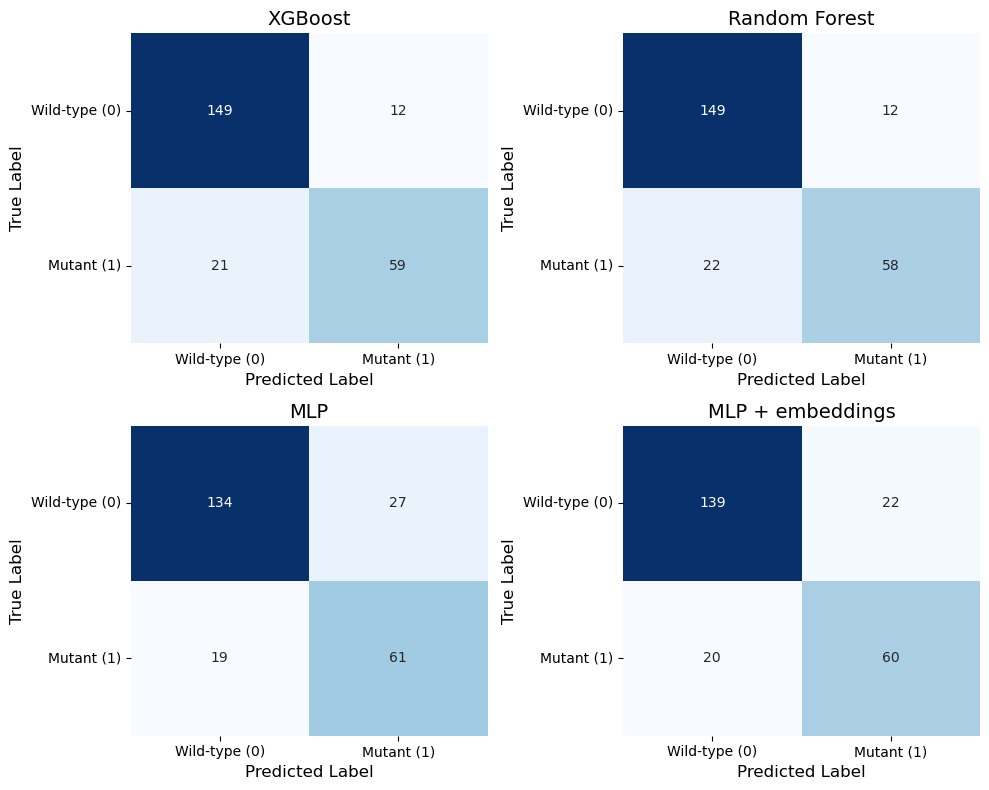

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
titles = ["XGBoost", "Random Forest",
          "MLP", "MLP + embeddings"]
cms    = [cm_xgb, cm_rf, cm_mlp, cm_mlp_emb]

for ax, title, cm in zip(axes.flatten(), titles, cms):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_xticklabels(["Wild-type (0)", "Mutant (1)"])
    ax.set_yticklabels(["Wild-type (0)", "Mutant (1)"], rotation=0)

plt.tight_layout()
plt.show()

Our best model turns out to be XGBoost with hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 5, 'subsample': 0.8}. 
It achieves an accuracy of 86.3% and F1 Score 78.1%.

# Task 2 - multiclass classification

In [284]:
y_train = y_train_multiclass
y_test = y_test_multiclass

For this task we will try to classify our samples in the following classes:

- WT (Wild Type): No mutation is present.
- SNP (Single Nucleotide Polymorphism): A single base pair in the DNA sequence is changed.
- DEL (Deletion): One or more nucleotides have been removed from the DNA sequence.
- INS (Insertion): One or more nucleotides have been added to the DNA sequence.
- DNP (Double Nucleotide Polymorphism): Two adjacent base pairs have been modified.

In [285]:
print(f"Training data shape: {X_train.shape}")
print(f"Training labels distribution:\n{y_train.value_counts()}")
print()
print(f"Testing data shape: {X_test.shape}")
print(f"Testing labels distribution:\n{y_test.value_counts()}")

Training data shape: (962, 335)
Training labels distribution:
Variant_Type
WT              642
SNP             265
DEL              37
INS              14
DNP               4
Name: count, dtype: int64

Testing data shape: (241, 335)
Testing labels distribution:
Variant_Type
WT              161
SNP              66
DEL               9
INS               4
DNP               1
Name: count, dtype: int64


This multi-class classification task involves an imbalanced dataset, where certain TP53 mutation types are significantly more frequent than others. To ensure a fair evaluation of model performance we will rely on weighted metrics.

Moreover, the 'DNP' mutation occurs in very few samples, so we exclude them to avoid introducing bias that could adversely affect the performance of the classification model.

In [286]:
train_mask = y_train.iloc[:, 0] != 'DNP'
X_train = X_train.loc[train_mask].reset_index(drop=True)
y_train = y_train.loc[train_mask].reset_index(drop=True)

test_mask = y_test.iloc[:, 0] != 'DNP'
X_test = X_test.loc[test_mask].reset_index(drop=True)
y_test = y_test.loc[test_mask].reset_index(drop=True)

In [287]:
# Flatten and encode
y_train_flat = y_train.iloc[:, 0].values
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_flat)

y_test_flat = y_test.iloc[:, 0].values
y_test = label_encoder.transform(y_test_flat)

### XGBoost

In [ ]:
num_classes = 4

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    eval_metric='mlogloss',
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda': [1, 5],
    'reg_alpha': [0, 1]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=cv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_xgb_multiclass = grid_search.best_estimator_
y_pred = best_xgb_multiclass.predict(X_test)
y_proba = best_xgb_multiclass.predict_proba(X_test)

print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
print("Classification Report:\n", classification_report(y_test, y_pred))

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 0.8}
Accuracy: 0.8125
F1 Score: 0.7905508892350998
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.00      0.00      0.00         4
           2       0.69      0.70      0.69        66
           3       0.87      0.93      0.89       161

    accuracy                           0.81       240
   macro avg       0.39      0.41      0.40       240
weighted avg       0.77      0.81      0.79       240



### Random forest

In [ ]:
rf_model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt', 0.5, 1.0],
    'bootstrap': [True]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=cv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf_multiclass = grid_search.best_estimator_
y_pred = best_rf_multiclass.predict(X_test)
y_proba = best_rf_multiclass.predict_proba(X_test)[:, 1]

print("Best Hyperparameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Hyperparameters: {'bootstrap': True, 'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Accuracy: 0.8166666666666667
F1 Score: 0.7899704724409449
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.00      0.00      0.00         4
           2       0.70      0.65      0.68        66
           3       0.85      0.95      0.90       161

    accuracy                           0.82       240
   macro avg       0.39      0.40      0.39       240
weighted avg       0.77      0.82      0.79       240



### MLP

In [ ]:
mlp = MLPClassifier(
    random_state=42,
    early_stopping=True,  
    validation_fraction=0.1, 
    max_iter=200,             
    tol=1e-4,               
    verbose=False
)

param_grid = {
    'hidden_layer_sizes': [(256, 128), (512, 256), (128,)],
    'activation': ['relu', 'tanh'],
    'alpha': [1e-4, 1e-3, 1e-2],
    'learning_rate_init': [1e-3, 5e-4],
    'learning_rate': ['constant', 'adaptive'],
    'batch_size': [32, 64]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_nn = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1
)


grid_search_nn.fit(X_train, y_train)

best_mlp_multiclass = grid_search_nn.best_estimator_

y_pred  = best_mlp_multiclass.predict(X_test)
y_proba = best_mlp_multiclass.predict_proba(X_test)[:, 1]

print("Best Hyperparameters:", grid_search_nn.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
print("Classification Report:\n", classification_report(y_test, y_pred))

Best Hyperparameters: {'activation': 'tanh', 'alpha': 0.0001, 'batch_size': 32, 'hidden_layer_sizes': (512, 256), 'learning_rate': 'constant', 'learning_rate_init': 0.001}
Accuracy: 0.7666666666666667
F1 Score: 0.741108191986234
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.00      0.00      0.00         4
           2       0.61      0.58      0.59        66
           3       0.82      0.91      0.86       161

    accuracy                           0.77       240
   macro avg       0.36      0.37      0.36       240
weighted avg       0.72      0.77      0.74       240



### Andrea's embeddings 

In [288]:
gene_emb_df = pd.read_csv("../DATA/embeddings_dataset.csv", sep=';')
gene_emb_df

,ensembl_id,gene_name,description,embeddings
0,ENSG00000273106,PPM1B-DT,"is an rna gene, and is affiliated with the lnc...","[0.7153338, -0.11398319, -2.0761514, 0.5069085..."
1,ENSG00000038532,CLEC16A,this gene encodes member of the domain family....,"[0.36557245, 1.0013258, -0.0023882652, 0.54005..."
2,ENSG00000181856,SLC2A4,this gene is member of the carrier family faci...,"[-0.21235171, 2.9689298, 0.035055883, -0.12451..."
3,ENSG00000262703,ENSG00000262703,"novel transcript, antisense to rmi2 is an rna ...","[0.3950196, 1.5300467, -1.4824657, 1.1461742, ..."
4,ENSG00000090661,CERS4,enables sphingosine n-acyltransferase activity...,"[1.4770727, 0.21068904, -0.44252306, -0.483786..."
...,...,...,...,...
22835,ENSG00000275111,ZNF2,the protein encoded by this gene belongs to th...,"[-0.37485185, 0.9992399, 0.3704633, 0.41376647..."
22836,ENSG00000171953,ATPAF2,this gene encodes factor for the f1 component ...,"[-0.44170868, -0.9684407, 0.9719296, -0.525657..."
22837,ENSG00000198650,TAT,nuclear gene encodes mitochondrial protein whi...,"[0.36593568, 1.2355629, -0.5669457, 0.7016244,..."
22838,ENSG00000226696,LENG8-AS1,"rna is rna gene, is with the class.","[1.0164974, 0.8513611, -1.4877115, -1.7738836,..."


In [289]:
shared_genes = [g for g in X_train.columns if g in gene_emb_df["gene_name"].values]
print(f"Using {len(shared_genes)}/{len(X_train.columns)} gene embeddings.")

Using 301/335 gene embeddings.


In [290]:
filtered_embeddings_df = gene_emb_df.set_index("gene_name").loc[shared_genes]
filtered_embeddings_df = filtered_embeddings_df.reindex(shared_genes)

In [291]:
# Convert string representations back to arrays
embeddings_list = [ast.literal_eval(emb) for emb in filtered_embeddings_df["embeddings"].values]
embeddings_matrix = np.vstack(embeddings_list)
print("Embeddings matrix shape:", embeddings_matrix.shape)

Embeddings matrix shape: (301, 768)


In [ ]:
def compute_cell_embeddings_from_df(expr_df, embeddings_matrix, shared_genes):
    """
    expr_df: pandas DataFrame (n_cells, n_genes_subset), columns include shared_genes
    embeddings_matrix: np.array of shape (n_shared_genes, embed_dim)
    shared_genes: list of gene names in exactly the same order as embeddings_matrix rows

    Returns:
    - cell_embeddings: np.array of shape (n_cells, embed_dim)
    """
    expr_shared = expr_df[shared_genes].values 

    row_sums = expr_shared.sum(axis=1, keepdims=True)
    normalized_counts = expr_shared / (row_sums + 1e-6) 

    cell_embeddings = normalized_counts.dot(embeddings_matrix) 
    return cell_embeddings

In [ ]:
X_train_emb = compute_cell_embeddings_from_df(X_train, embeddings_matrix, shared_genes)
X_test_emb  = compute_cell_embeddings_from_df(X_test, embeddings_matrix, shared_genes)

print("X_train_emb shape:", X_train_emb.shape) 
print("X_test_emb shape:",  X_test_emb.shape) 

X_train_emb shape: (958, 768)
X_test_emb shape: (240, 768)


In [ ]:
mlp = MLPClassifier(
    random_state=42,
    early_stopping=True,    
    validation_fraction=0.1, 
    max_iter=200,           
    tol=1e-4,              
    verbose=False
)

param_grid = {
    'hidden_layer_sizes': [(256, 128), (512, 256), (128,)],
    'activation': ['relu', 'tanh'],
    'alpha': [1e-4, 1e-3, 1e-2],
    'learning_rate_init': [1e-3, 5e-4],
    'learning_rate': ['constant', 'adaptive'],
    'batch_size': [32, 64]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_nn = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1
)


grid_search_nn.fit(X_train_emb, y_train)

best_mlp_emb_multiclass = grid_search_nn.best_estimator_

y_pred  = best_mlp_emb_multiclass.predict(X_test_emb)
y_proba = best_mlp_emb_multiclass.predict_proba(X_test_emb)[:, 1]


print("Best Hyperparameters:", grid_search_nn.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
print("Classification Report:\n", classification_report(y_test, y_pred))

Best Hyperparameters: {'activation': 'relu', 'alpha': 0.001, 'batch_size': 32, 'hidden_layer_sizes': (512, 256), 'learning_rate': 'constant', 'learning_rate_init': 0.001}
Accuracy: 0.7791666666666667
F1 Score: 0.758518347209374
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.00      0.00      0.00         4
           2       0.61      0.67      0.64        66
           3       0.85      0.89      0.87       161

    accuracy                           0.78       240
   macro avg       0.37      0.39      0.38       240
weighted avg       0.74      0.78      0.76       240



## Results

In [297]:
y_pred_xgb     = best_xgb_multiclass.predict(X_test)
y_pred_rf      = best_rf_multiclass.predict(X_test)
y_pred_mlp     = best_mlp_multiclass.predict(X_test)
y_pred_mlp_emb = best_mlp_emb_multiclass.predict(X_test_emb)

classes = list(np.unique(y_test))

cm_xgb     = confusion_matrix(y_test,      y_pred_xgb,     labels=classes)
cm_rf      = confusion_matrix(y_test,      y_pred_rf,      labels=classes)
cm_mlp     = confusion_matrix(y_test,      y_pred_mlp,     labels=classes)
cm_mlp_emb = confusion_matrix(y_test,      y_pred_mlp_emb, labels=classes)

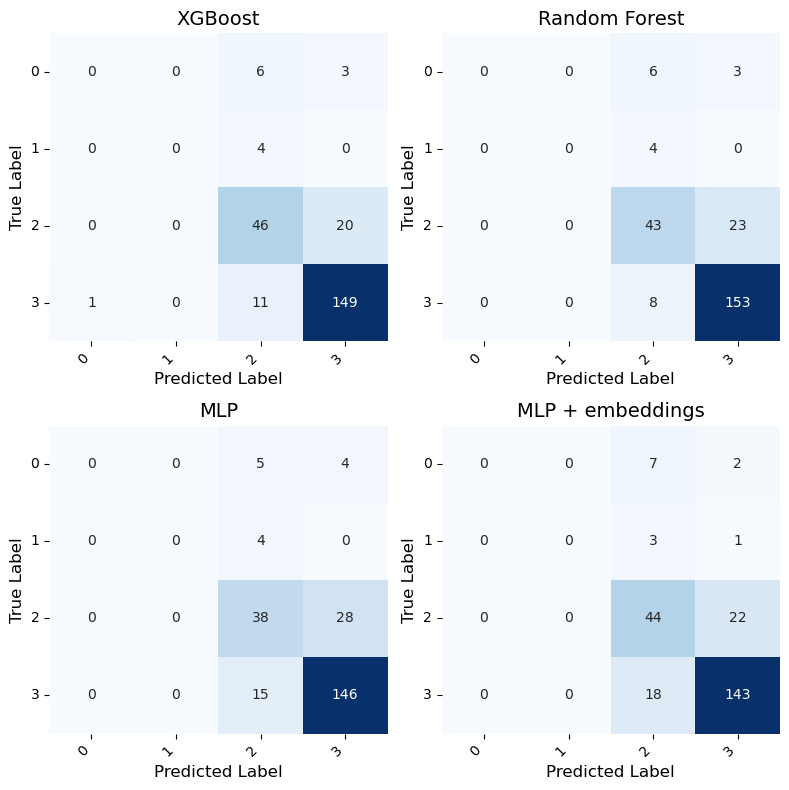

In [303]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
titles = [
    "XGBoost", 
    "Random Forest",
    "MLP", 
    "MLP + embeddings"
]
cms    = [cm_xgb, cm_rf, cm_mlp, cm_mlp_emb]

for ax, title, cm in zip(axes.flatten(), titles, cms):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_xticks(np.arange(len(classes)) + 0.5)
    ax.set_yticks(np.arange(len(classes)) + 0.5)
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_yticklabels(classes, rotation=0)

plt.tight_layout()
plt.show()

Our best model in predicting which type of mutation we incured is XGBoost with hyper-parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 0.8}. It achieved an accuracy of 81.3%.

However, across all tested classifiers, the confusion matrices reveal a consistent inability to correctly classify instances of class 'INS' and class 'DEL'. This likely stems from a combination of two factors: 
- severe class imbalance, with classes 0 and 1 being underrepresented during training
- low feature separability from class 'WT', leading models to consistently misclassify them as belonging to that majority class. The failure persists even in high-capacity models (XGBoost, MLP), which rules out model complexity as the cause and reinforces the hypothesis that the issue lies in the training data distribution or representation quality.